In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
print("Project root added to sys.path")

Project root added to sys.path


In [2]:
import torch
import torch.nn 
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

from clients.federated_training import federated_training
from utils.data_partition import dirichlet_partition


torch.manual_seed(42)
np.random.seed(42)

c:\Users\la7tim\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [3]:

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    
    
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)
    
    
num_clients = 5
partitions = {
    "dirichlet_iid":      dirichlet_partition(train_dataset, num_clients=num_clients, alpha=1000.0),  # High alpha -> IID-like
    "dirichlet_noniid":   dirichlet_partition(train_dataset, num_clients=num_clients, alpha=0.01),   # Low alpha -> non-IID
    "dirichlet_medium":   dirichlet_partition(train_dataset, num_clients=num_clients, alpha=0.5),   # Medium skew
}



c:\Users\la7tim\Desktop\Internship\FedTinyProp\utils\data_partition.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels = np.array(dataset.targets)


c:\Users\la7tim\Desktop\Internship\FedTinyProp\utils\partitions_visualization.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(dataset.targets)


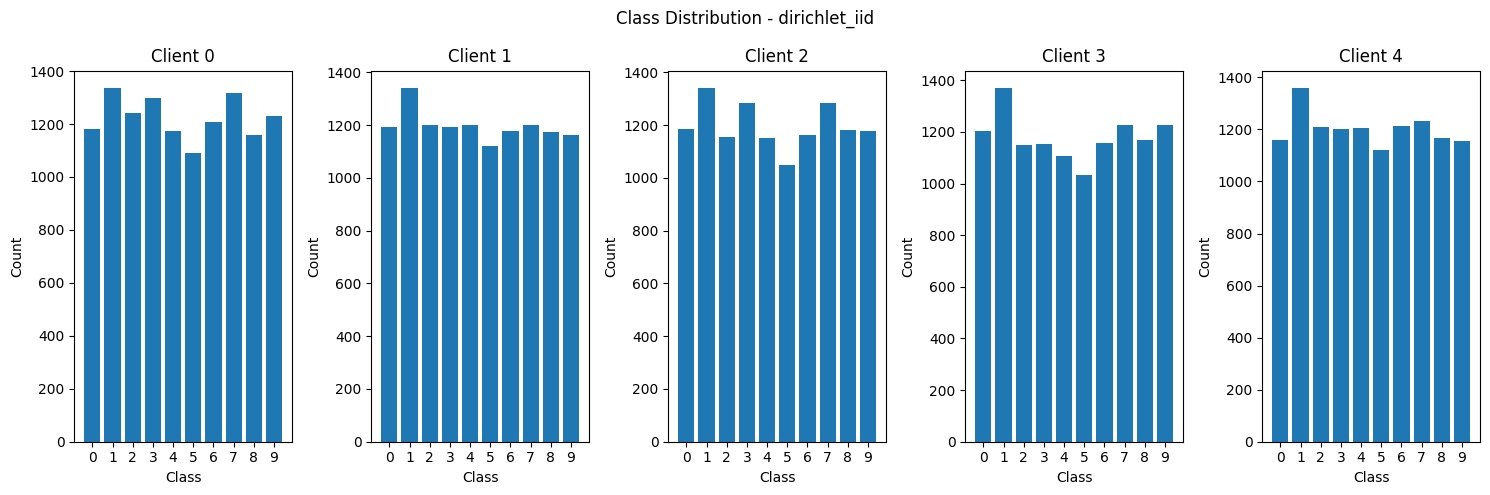

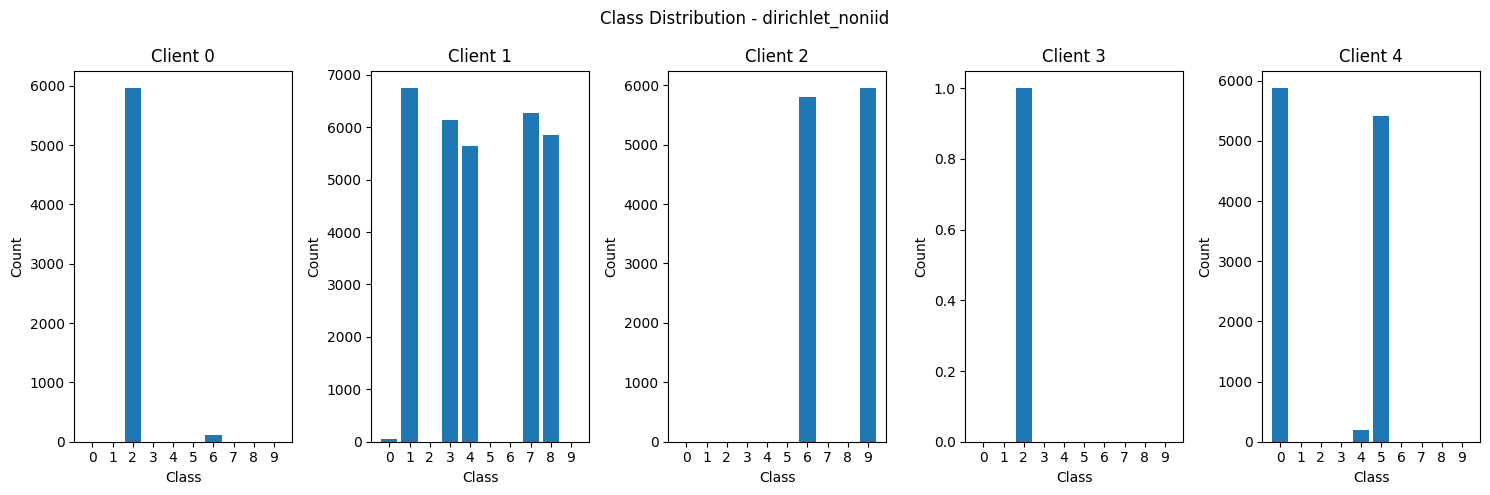

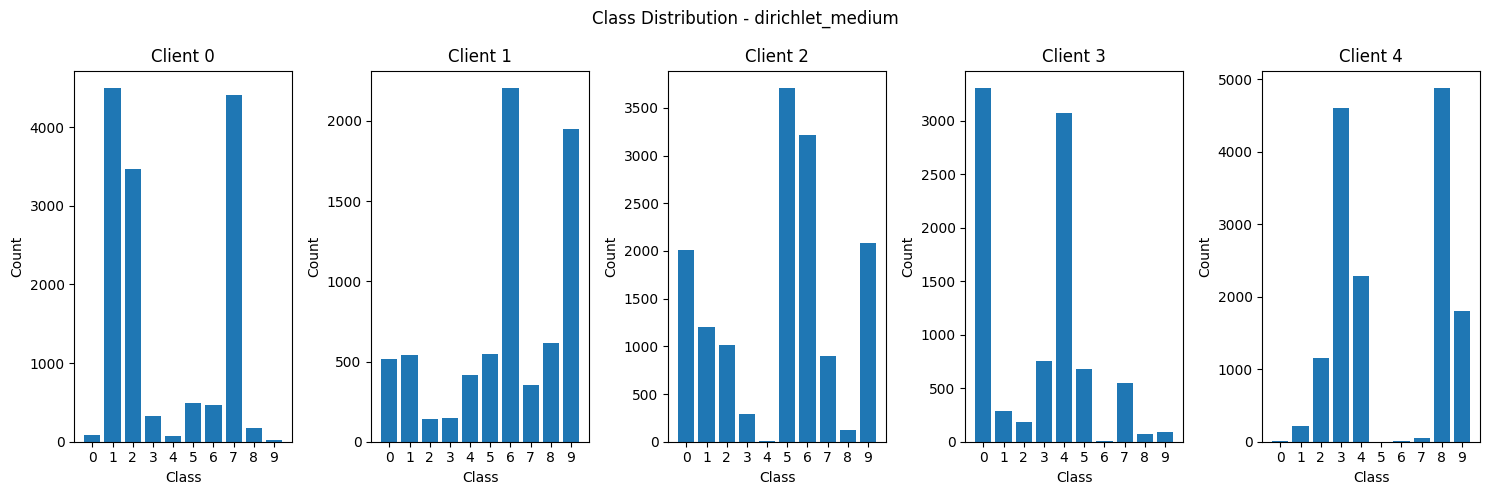

In [4]:
from utils.partitions_visualization import plot_class_distribution
for name, part in partitions.items():
    fig = plot_class_distribution(part, train_dataset, title=f"Class Distribution - {name}")
    fig.savefig(f"results/class_distribution_{name}.png")  # Optional: Save the plot
    plt.show()


In [6]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Union

def plot_partition_heatmap(partitions: Union[List[List[int]], Dict[int, List[int]]], dataset, title="Client-Class Distribution Heatmap"):
    if hasattr(dataset, 'targets'):
        targets = np.array(dataset.targets)
    else:
        targets = np.array([dataset[i][1] for i in range(len(dataset))])
    
    num_classes = len(np.unique(targets))
    
    if isinstance(partitions, dict):
        partitions = list(partitions.values())

    num_clients = len(partitions)

    # Create client-class count matrix
    data_matrix = np.zeros((num_clients, num_classes), dtype=int)

    for client_idx, indices in enumerate(partitions):
        labels = targets[indices]
        for class_idx in range(num_classes):
            data_matrix[client_idx, class_idx] = np.sum(labels == class_idx)

    # Convert to DataFrame for seaborn
    df = pd.DataFrame(data_matrix, columns=[f"Class {i}" for i in range(num_classes)])
    df.index = [f"Client {i}" for i in range(num_clients)]

    # Plot heatmap
    plt.figure(figsize=(12, 6))
    sns.heatmap(df, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={"label": "Sample Count"})
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Client")
    plt.tight_layout()
    plt.show()


C:\Users\la7tim\AppData\Local\Temp\ipykernel_13520\723030216.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(dataset.targets)


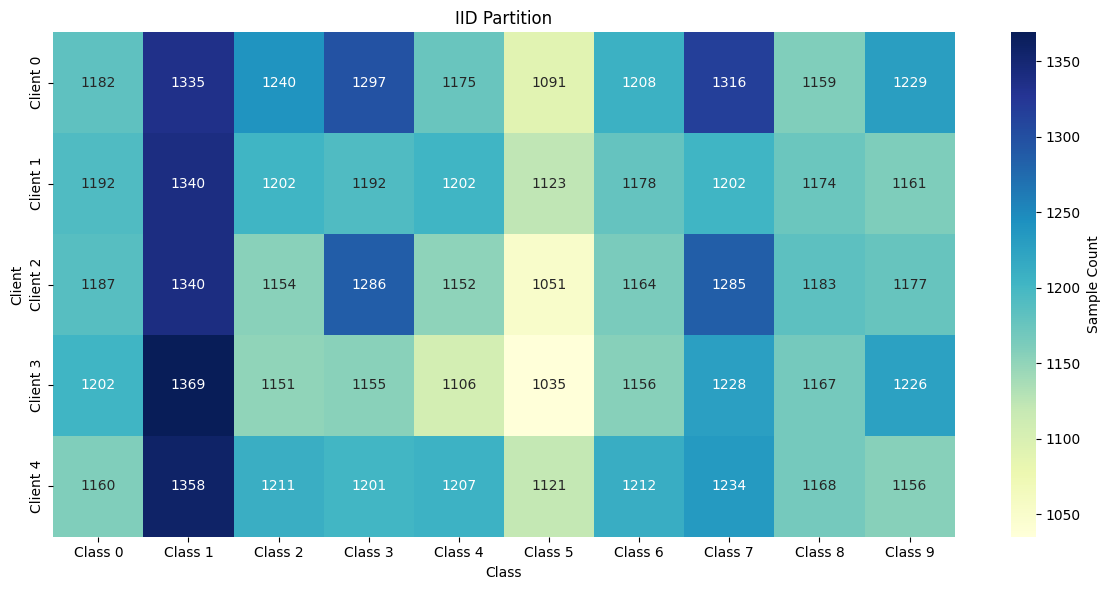

C:\Users\la7tim\AppData\Local\Temp\ipykernel_13520\723030216.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(dataset.targets)


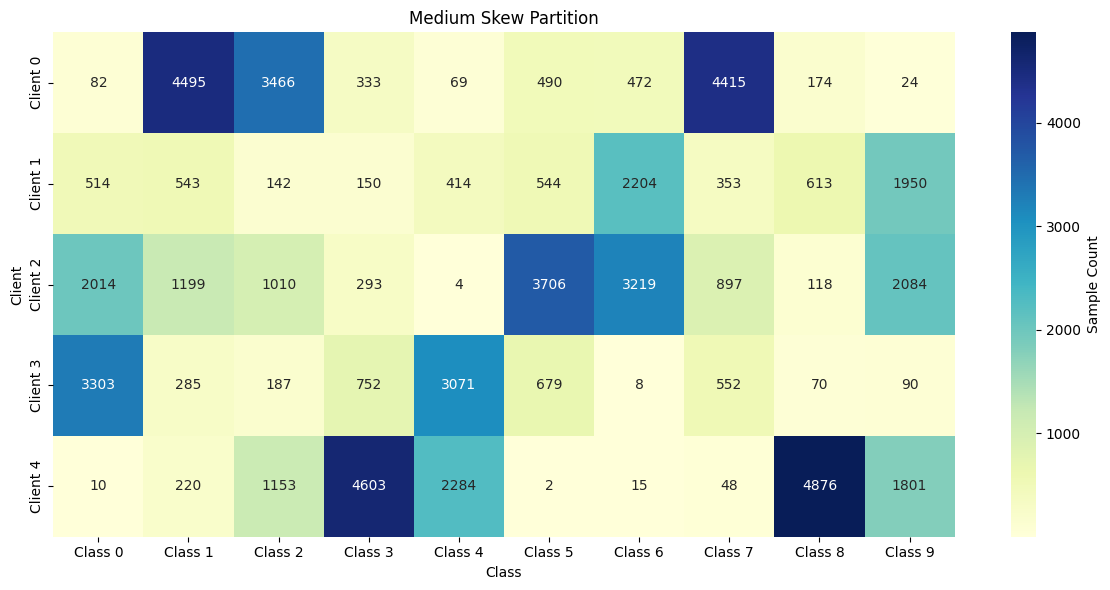

C:\Users\la7tim\AppData\Local\Temp\ipykernel_13520\723030216.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(dataset.targets)


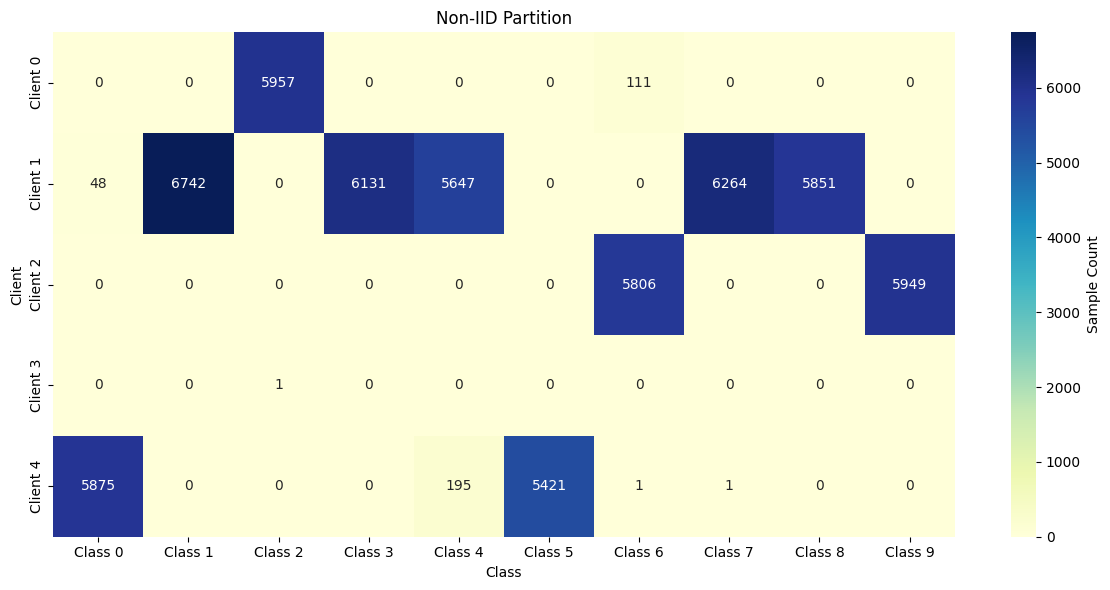

In [7]:
plot_partition_heatmap(partitions["dirichlet_iid"], train_dataset, "IID Partition")
plot_partition_heatmap(partitions["dirichlet_medium"], train_dataset, "Medium Skew Partition")
plot_partition_heatmap(partitions["dirichlet_noniid"], train_dataset, "Non-IID Partition")
